# 05 - Transfer Learning (DenseNet-121) for Brain Tumor Detection

This notebook implements **Transfer Learning** using a pre-trained **DenseNet-121** backbone. DenseNet is widely recognized as an industry standard for medical imaging due to its dense feature reuse. We leverage our augmented `.pt` tensors, apply an optimized fine-tuning learning rate (`1e-4`), use Early Stopping, and evaluate all classification metrics.

In [1]:
import os
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from dotenv import load_dotenv

# Add src directory to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models import TransferCNN
from src.training import train_advanced_cnn_with_early_stopping
from src.evaluation import evaluate_cnn_model

%matplotlib inline
sns.set_theme(style="whitegrid")
load_dotenv()

True

## 1. Load Augmented Tensors & Split into Train / Validation / Test

In [13]:
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("data", "processed"))
AUG_DIR = os.path.join(PROCESSED_DIR, "augmented_images")
AUG_DIR_224x224 = os.getenv("AUG_DIR_224x224", os.path.join(PROCESSED_DIR, "augmented_images_224x224"))
if not os.path.exists(AUG_DIR):
    AUG_DIR = os.path.join("..", "data", "processed", "augmented_images")

yes_aug_dir = os.path.join(AUG_DIR_224x224, "yes")
no_aug_dir = os.path.join(AUG_DIR_224x224, "no")

images = []
labels = []

if os.path.exists(no_aug_dir):
    for file in os.listdir(no_aug_dir):
        if file.endswith('.pt'):
            images.append(torch.load(os.path.join(no_aug_dir, file)))
            labels.append(0)

if os.path.exists(yes_aug_dir):
    for file in os.listdir(yes_aug_dir):
        if file.endswith('.pt'):
            images.append(torch.load(os.path.join(yes_aug_dir, file)))
            labels.append(1)

print(f"Total loaded tensors (.pt): {len(images)}")

# Split: 70% Train, 15% Validation (for Early Stopping), 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(images, labels, test_size=0.15, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp)

print(f"Train set: {len(X_train)} | Validation set: {len(X_val)} | Test set: {len(X_test)}")

Total loaded tensors (.pt): 504
Train set: 352 | Validation set: 76 | Test set: 76


## 2. Initialize and Train Transfer Learning Model (DenseNet-121)
We use a lower learning rate (`1e-4`) with AdamW to carefully fine-tune the pre-trained weights without destabilizing feature extractors.

In [14]:
print("=== Initializing DenseNet-121 Transfer Learning Model ===")
transfer_model = TransferCNN(model_name='densenet121', num_classes=2, freeze_base=False)

trained_transfer, history_transfer, best_acc_transfer = train_advanced_cnn_with_early_stopping(
    model=transfer_model, 
    train_images=X_train, train_labels=y_train,
    val_images=X_val, val_labels=y_val, 
    optimizer_type='AdamW',
    lr=0.0001,             # Lower learning rate for fine-tuning pre-trained weights
    epochs=200, 
    batch_size=32, 
    patience=20
)

print(f"\nTransfer Learning Best Validation Accuracy: {best_acc_transfer:.2f}%")

=== Initializing DenseNet-121 Transfer Learning Model ===
 Chargement des poids locaux DenseNet-121 depuis : ../models\densenet121-a639ec97.pth
Epoch [1/200] | Train Loss: 0.6362 | Val Accuracy: 38.16%
   ✨ Meilleure accuracy validation : 38.16% (Poids sauvegardés)
Epoch [2/200] | Train Loss: 0.4704 | Val Accuracy: 38.16%
   ⏳ Stagnation (1/20)
Epoch [3/200] | Train Loss: 0.4189 | Val Accuracy: 38.16%
   ⏳ Stagnation (2/20)
Epoch [4/200] | Train Loss: 0.3457 | Val Accuracy: 38.16%
   ⏳ Stagnation (3/20)
Epoch [5/200] | Train Loss: 0.2750 | Val Accuracy: 38.16%
   ⏳ Stagnation (4/20)
Epoch [6/200] | Train Loss: 0.2236 | Val Accuracy: 55.26%
   ✨ Meilleure accuracy validation : 55.26% (Poids sauvegardés)
Epoch [7/200] | Train Loss: 0.1815 | Val Accuracy: 76.32%
   ✨ Meilleure accuracy validation : 76.32% (Poids sauvegardés)
Epoch [8/200] | Train Loss: 0.1207 | Val Accuracy: 82.89%
   ✨ Meilleure accuracy validation : 82.89% (Poids sauvegardés)
Epoch [9/200] | Train Loss: 0.1022 | Val Acc

In [15]:
print("=== Initializing ResNet-50 Transfer Learning Model ===")
transfer_model_resnet50 = TransferCNN(model_name='resnet50', num_classes=2, freeze_base=False)

trained_transfer_resnet50, history_transfer_resnet50, best_acc_transfer_resnet50 = train_advanced_cnn_with_early_stopping(
    model=transfer_model_resnet50, 
    train_images=X_train, train_labels=y_train,
    val_images=X_val, val_labels=y_val, 
    optimizer_type='AdamW',
    lr=0.0001,             # Lower learning rate for fine-tuning pre-trained weights
    epochs=200, 
    batch_size=32, 
    patience=20
)

print(f"\nTransfer Learning Best Validation Accuracy: {best_acc_transfer_resnet50:.2f}%")

=== Initializing ResNet-50 Transfer Learning Model ===
 Chargement des poids locaux ResNet-50 depuis : ../models\resnet50-11ad3fa6.pth
Epoch [1/200] | Train Loss: 0.6212 | Val Accuracy: 68.42%
   ✨ Meilleure accuracy validation : 68.42% (Poids sauvegardés)
Epoch [2/200] | Train Loss: 0.3555 | Val Accuracy: 81.58%
   ✨ Meilleure accuracy validation : 81.58% (Poids sauvegardés)
Epoch [3/200] | Train Loss: 0.1454 | Val Accuracy: 85.53%
   ✨ Meilleure accuracy validation : 85.53% (Poids sauvegardés)
Epoch [4/200] | Train Loss: 0.0344 | Val Accuracy: 86.84%
   ✨ Meilleure accuracy validation : 86.84% (Poids sauvegardés)
Epoch [5/200] | Train Loss: 0.0136 | Val Accuracy: 88.16%
   ✨ Meilleure accuracy validation : 88.16% (Poids sauvegardés)
Epoch [6/200] | Train Loss: 0.0049 | Val Accuracy: 92.11%
   ✨ Meilleure accuracy validation : 92.11% (Poids sauvegardés)
Epoch [7/200] | Train Loss: 0.0042 | Val Accuracy: 94.74%
   ✨ Meilleure accuracy validation : 94.74% (Poids sauvegardés)
Epoch [8/20

## 3. Comprehensive Test Evaluation & Metrics (Accuracy, Precision, Recall, F1-Score)

In [16]:
metrics_transfer, preds_transfer, true_transfer = evaluate_cnn_model(trained_transfer, X_test, y_test)
metrics_transfer_resnet50, preds_transfer_resnet50, true_transfer_resnet50 = evaluate_cnn_model(trained_transfer_resnet50, X_test, y_test)
# Build performance dataframe
transfer_df = pd.DataFrame([
    {
        "Model": "DenseNet-121 (Transfer Learning)",
        "Accuracy": metrics_transfer["Accuracy"],
        "Precision": metrics_transfer["Precision"],
        "Recall": metrics_transfer["Recall"],
        "F1-Score": metrics_transfer["F1-Score"]
    },
    {
        "Model": "ResNet-50 (Transfer Learning)",
        "Accuracy": metrics_transfer_resnet50["Accuracy"],
        "Precision": metrics_transfer_resnet50["Precision"],
        "Recall": metrics_transfer_resnet50["Recall"],
        "F1-Score": metrics_transfer_resnet50["F1-Score"]
    }
])

print("=== TRANSFER LEARNING PERFORMANCE SUMMARY ===")
display(transfer_df.style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], cmap='Greens'))

=== TRANSFER LEARNING PERFORMANCE SUMMARY ===


,Model,Accuracy,Precision,Recall,F1-Score
0,DenseNet-121 (Transfer Learning),0.894737,0.895833,0.934783,0.914894
1,ResNet-50 (Transfer Learning),0.986842,0.978723,1.000000,0.989247


## 4. Visualizations: Training Curves & Confusion Matrix

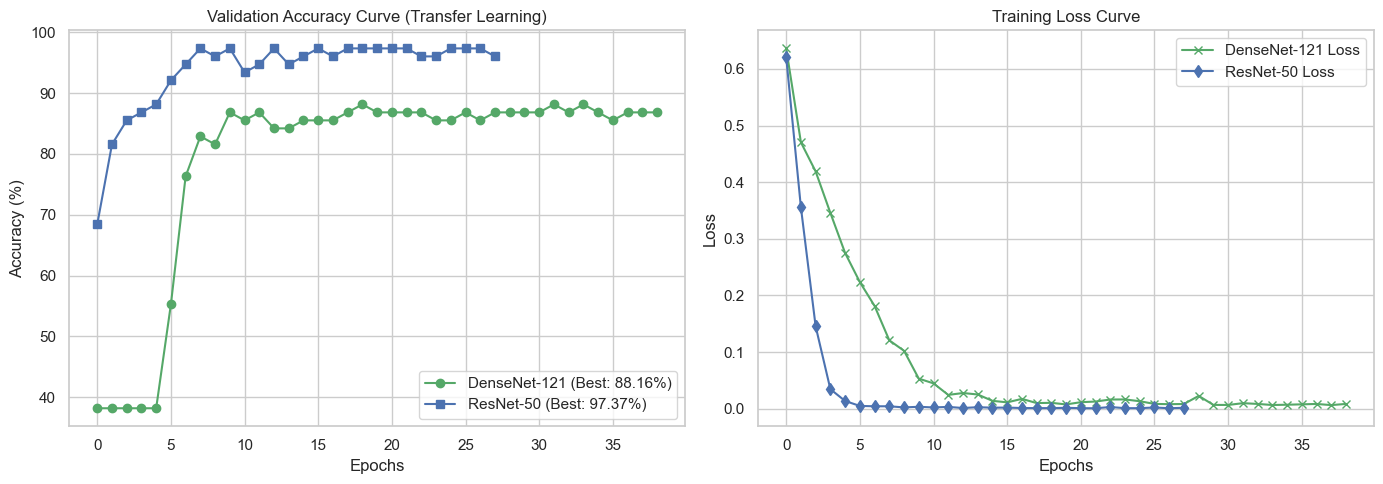

<Figure size 500x400 with 0 Axes>

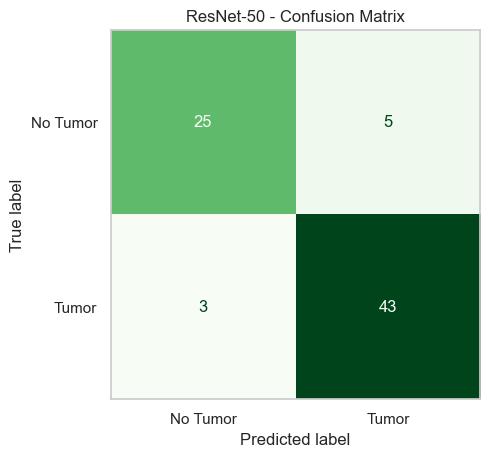

In [18]:
plt.figure(figsize=(14, 5))

# Validation Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history_transfer['val_accuracy'], marker='o', color='g', label=f'DenseNet-121 (Best: {max(history_transfer["val_accuracy"]):.2f}%)')
plt.plot(history_transfer_resnet50['val_accuracy'], marker='s', color='b', label=f'ResNet-50 (Best: {max(history_transfer_resnet50["val_accuracy"]):.2f}%)')
plt.title('Validation Accuracy Curve (Transfer Learning)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Training Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history_transfer['train_loss'], marker='x', color='g', label='DenseNet-121 Loss')
plt.plot(history_transfer_resnet50['train_loss'], marker='d', color='b', label='ResNet-50 Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=metrics_transfer["Confusion Matrix"], display_labels=['No Tumor', 'Tumor']).plot(colorbar=False, cmap='Greens')
plt.title('ResNet-50 - Confusion Matrix')
plt.grid(False)
plt.show()

In [22]:
import os
import torch

# Définition du dossier de sauvegarde
save_dir = os.path.join("..", "models")
if not os.path.exists(save_dir):
    save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

# Dictionnaire associant le nom du fichier aux variables potentielles de vos notebooks
models_to_save = {
    "resnet50__retrained.pth": locals().get("trained_transfer_resnet50", None),
    "densenet121_retrained.pth": locals().get("trained_transfer", None)
}

saved_count = 0
print("💾 Sauvegarde des modèles entraînés en cours...")

for filename, model_instance in models_to_save.items():
    if model_instance is not None:
        file_path = os.path.join(save_dir, filename)
        # Sauvegarde des poids (recommandé par rapport au modèle complet)
        torch.save(model_instance.state_dict(), file_path)
        print(f"   ✅ Sauvegardé : {file_path}")
        saved_count += 1

print(f"\n✨ Opération terminée ! {saved_count} modèle(s) sauvegardé(s) dans '{save_dir}'.")

💾 Sauvegarde des modèles entraînés en cours...
   ✅ Sauvegardé : ..\models\resnet50__retrained.pth
   ✅ Sauvegardé : ..\models\densenet121_retrained.pth

✨ Opération terminée ! 2 modèle(s) sauvegardé(s) dans '..\models'.
